import sys
sys.version

In [2]:
%pip install numpy pandas scikit-learn nltk

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy
import pandas
import sklearn #TF-IDF, LOGISTIC REGRESSION
import nltk #VADER
print("All core imports successful")

All core imports successful


In [ ]:
%pip install datasets # library from huggingface to load datasets

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [52]:
from datasets import load_dataset
%pip install ipywidgets
dataset = load_dataset("sst2")

dataset

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1821
    })
})

In [6]:
dataset["train"][0:5]

{'idx': [0, 1, 2, 3, 4],
 'sentence': ['hide new secretions from the parental units ',
  'contains no wit , only labored gags ',
  'that loves its characters and communicates something rather beautiful about human nature ',
  'remains utterly satisfied to remain the same throughout ',
  'on the worst revenge-of-the-nerds clichés the filmmakers could dredge up '],
 'label': [0, 0, 1, 0, 0]}

In [7]:
import nltk
nltk.download("vader_lexicon")

# vader_lexicon = sentiment word dictionary
# VADER = rules + lexicon, no learning

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\chiya\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [8]:
from nltk.sentiment import SentimentIntensityAnalyzer
vader = SentimentIntensityAnalyzer()

# This creates the analyzer object
# No training happens (rule-based)
# Its ready to score text

In [9]:
#comparison bw train and test
text = dataset["train"][0]["sentence"]
label = dataset["train"][0]["label"]

scores = vader.polarity_scores(text)

print("Text:", text)
print("True label:", label)
print("VADER scores:", scores)

Text: hide new secretions from the parental units 
True label: 0
VADER scores: {'neg': 0.221, 'neu': 0.779, 'pos': 0.0, 'compound': -0.1779}


In [10]:
def vader_predict(text):
    scores = vader.polarity_scores(text)
    compound = scores["compound"]

    pred = 1 if compound >= 0 else 0
    confidence = abs(compound)

    return pred, confidence

In [11]:
#testing VADER with multiple sentences
for i in range(5):
    text = dataset["train"][i]["sentence"]
    true_label = dataset["train"][i]["label"]
    
    pred, conf = vader_predict(text)
    
    print(f"Text       : {text}")
    print(f"True label : {true_label}")
    print(f"VADER pred : {pred}, confidence: {conf:.3f}")
    print("-" * 60)


Text       : hide new secretions from the parental units 
True label : 0
VADER pred : 0, confidence: 0.178
------------------------------------------------------------
Text       : contains no wit , only labored gags 
True label : 0
VADER pred : 0, confidence: 0.296
------------------------------------------------------------
Text       : that loves its characters and communicates something rather beautiful about human nature 
True label : 1
VADER pred : 1, confidence: 0.823
------------------------------------------------------------
Text       : remains utterly satisfied to remain the same throughout 
True label : 0
VADER pred : 1, confidence: 0.475
------------------------------------------------------------
Text       : on the worst revenge-of-the-nerds clichés the filmmakers could dredge up 
True label : 0
VADER pred : 0, confidence: 0.625
------------------------------------------------------------


## TF-IDF + LOGISTIC REGRESSION

In [12]:
#preparing the data(minimal, on purpose)
from sklearn.model_selection import train_test_split

texts = [x["sentence"] for x in dataset["train"]]
labels = [x["label"] for x in dataset["train"]]

X_train, X_val, y_train, y_val = train_test_split(texts, labels, test_size = 0.2, random_state = 42)

# TF-IDF must be trained
# We need a validation split
# We do NOT touch the test set yet

In [13]:
#converting text to numbers (TF-IDF thingy)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

# Models cannot read text. 

# TF-IDF turns text into:
# Numbers
# Based on word importance
# High value = informative word
# Low value = common junk

# Why (1,2) ngrams:
# Captures phrases like “not good”
# Pure unigrams miss negation patterns

In [14]:
#training logistic regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [15]:
from sklearn.metrics import accuracy_score

val_preds = lr.predict(X_val_tfidf)
acc = accuracy_score(y_val, val_preds)

print("Validation accuracy:", acc)

Validation accuracy: 0.8443207126948775


In [16]:
import numpy as np

def tfidf_predict(text):
    vec = tfidf.transform([text])
    
    probs = lr.predict_proba(vec)[0]
    pred = np.argmax(probs)
    confidence = np.max(probs)
    
    return pred, confidence

# For TF-IDF + LR:

# confidence ≈ distance from decision boundary
# It is a probability
# But it can still be wrong
# It is often overconfident on keyword-heavy text

# This is NOT like VADER.
    
# VADER confidence = rule strength
# TF-IDF confidence = classifier certainty

In [17]:
for i in range(5):
    text = dataset["train"][i]["sentence"]
    true_label = dataset["train"][i]["label"]
    
    pred, conf = tfidf_predict(text)
    
    print(f"Text        : {text}")
    print(f"True label  : {true_label}")
    print(f"TF-IDF pred : {pred}, confidence: {conf:.3f}")
    print("-" * 60)

Text        : hide new secretions from the parental units 
True label  : 0
TF-IDF pred : 1, confidence: 0.603
------------------------------------------------------------
Text        : contains no wit , only labored gags 
True label  : 0
TF-IDF pred : 0, confidence: 0.940
------------------------------------------------------------
Text        : that loves its characters and communicates something rather beautiful about human nature 
True label  : 1
TF-IDF pred : 1, confidence: 0.913
------------------------------------------------------------
Text        : remains utterly satisfied to remain the same throughout 
True label  : 0
TF-IDF pred : 0, confidence: 0.573
------------------------------------------------------------
Text        : on the worst revenge-of-the-nerds clichés the filmmakers could dredge up 
True label  : 0
TF-IDF pred : 0, confidence: 0.980
------------------------------------------------------------


In [18]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.11.0+cpu
False


In [19]:
import torch
import transformers
import sentencepiece

print("torch OK")
print("transformers OK")

torch OK
transformers OK


In [20]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

In [21]:
tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased-finetuned-sst-2-english"
)

transformer_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased-finetuned-sst-2-english"
)

transformer_model.eval()

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1657.27it/s]


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [22]:
import torch.nn.functional as F

def transformer_predict(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    with torch.no_grad():
        outputs = transformer_model(**inputs)

    probs = F.softmax(outputs.logits, dim=1)[0]
    pred = torch.argmax(probs).item()
    confidence = torch.max(probs).item()

    return pred, confidence


In [23]:
for i in range(5):
    text = dataset["train"][i]["sentence"]
    true_label = dataset["train"][i]["label"]

    pred, conf = transformer_predict(text)

    print(text)
    print("true:", true_label, "pred:", pred, "conf:", round(conf, 3))
    print("-" * 50)

hide new secretions from the parental units 
true: 0 pred: 0 conf: 0.998
--------------------------------------------------
contains no wit , only labored gags 
true: 0 pred: 0 conf: 1.0
--------------------------------------------------
that loves its characters and communicates something rather beautiful about human nature 
true: 1 pred: 1 conf: 1.0
--------------------------------------------------
remains utterly satisfied to remain the same throughout 
true: 0 pred: 0 conf: 0.98
--------------------------------------------------
on the worst revenge-of-the-nerds clichés the filmmakers could dredge up 
true: 0 pred: 0 conf: 1.0
--------------------------------------------------


In [24]:
i = 20  # intentionally NOT 0

text = dataset["train"][i]["sentence"]
true_label = dataset["train"][i]["label"]

v_pred, v_conf = vader_predict(text)
t_pred, t_conf = tfidf_predict(text)
tr_pred, tr_conf = transformer_predict(text)

def fail(pred, true):
    return int(pred != true)

meta_row = {
    "sentence": text,

    "true_label": true_label,

    "vader_pred": v_pred,
    "vader_conf": v_conf,
    "vader_failed": fail(v_pred, true_label),

    "tfidf_pred": t_pred,
    "tfidf_conf": t_conf,
    "tfidf_failed": fail(t_pred, true_label),

    "transformer_pred": tr_pred,
    "transformer_conf": tr_conf,
    "transformer_failed": fail(tr_pred, true_label),
}

meta_row


{'sentence': 'equals the original and in some ways even betters it ',
 'true_label': 1,
 'vader_pred': 1,
 'vader_conf': 0.3182,
 'vader_failed': 0,
 'tfidf_pred': np.int64(1),
 'tfidf_conf': np.float64(0.8054176273391207),
 'tfidf_failed': 0,
 'transformer_pred': 1,
 'transformer_conf': 0.9995759129524231,
 'transformer_failed': 0}

In [25]:
import pandas as pd
meta_rows = []
N = 500

for i in range(N):
    text = dataset["train"][i]["sentence"]
    true_label = dataset["train"][i]["label"]

    v_pred, v_conf = vader_predict(text)
    t_pred, t_conf = tfidf_predict(text)
    tr_pred, tr_conf = transformer_predict(text)

    meta_rows.append({
        "sentence": text,
        "true_label": true_label,

        "vader_pred": v_pred,
        "vader_conf": v_conf,
        "vader_failed": int(v_pred != true_label),

        "tfidf_pred": t_pred,
        "tfidf_conf": t_conf,
        "tfidf_failed": int(t_pred != true_label),

        "transformer_pred": tr_pred,
        "transformer_conf": tr_conf,
        "transformer_failed": int(tr_pred != true_label),
    })

meta_df = pd.DataFrame(meta_rows)


In [26]:
import sys
!{sys.executable} -m pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.79      0.82      5909
           1       0.84      0.89      0.87      7561

    accuracy                           0.84     13470
   macro avg       0.84      0.84      0.84     13470
weighted avg       0.84      0.84      0.84     13470

Confusion Matrix:
[[4650 1259]
 [ 838 6723]]
ROC-AUC: 0.9297839298755635
PR-AUC: 0.9460777567960801


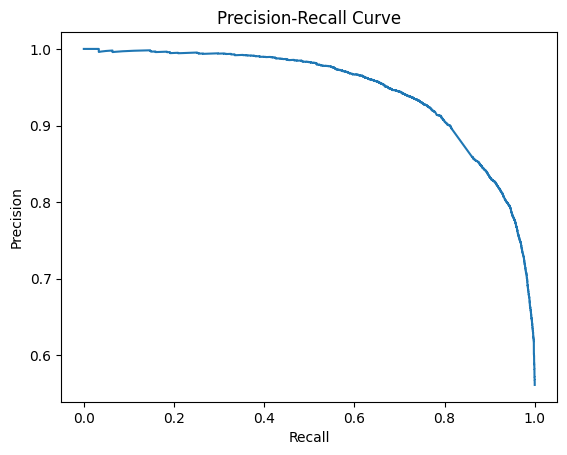

In [27]:

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

# Predictions
y_pred = lr.predict(X_val_tfidf)
y_prob = lr.predict_proba(X_val_tfidf)[:, 1]

# Classification report
print("Classification Report:")
print(classification_report(y_val, y_pred))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

# ROC-AUC
roc = roc_auc_score(y_val, y_prob)
print("ROC-AUC:", roc)

# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_val, y_prob)
pr_auc = auc(recall, precision)
print("PR-AUC:", pr_auc)

# Plot PR curve
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [28]:
meta_df.shape

(500, 11)

In [29]:
meta_df[["vader_failed", "tfidf_failed", "transformer_failed"]].mean()

vader_failed          0.304
tfidf_failed          0.130
transformer_failed    0.012
dtype: float64

In [30]:
meta_df.groupby("transformer_failed")["transformer_conf"].mean()

transformer_failed
0    0.996085
1    0.859784
Name: transformer_conf, dtype: float64

In [31]:
meta_df[["vader_failed", "tfidf_failed", "transformer_failed"]].mean()

vader_failed          0.304
tfidf_failed          0.130
transformer_failed    0.012
dtype: float64

In [32]:
(meta_df["vader_failed"] != meta_df["transformer_failed"]).mean()

np.float64(0.316)

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

import numpy as np

features = []
labels = []

for _, row in meta_df.iterrows():

    v_pred = row["vader_pred"]
    t_pred = row["tfidf_pred"]
    tr_pred = row["transformer_pred"]

    v_conf = row["vader_conf"]
    t_conf = row["tfidf_conf"]
    tr_conf = row["transformer_conf"]

    preds = [v_pred, t_pred, tr_pred]
    confs = [v_conf, t_conf, tr_conf]

    disagreement = len(set(preds)) / 3
    conf_std = np.std(confs)

    X = [v_conf, t_conf, tr_conf, disagreement, conf_std]

    failure = 1 if (
        disagreement > 0.4
        or (tr_conf < 0.6 and conf_std > 0.25)
    ) else 0

    features.append(X)
    labels.append(failure)

print("Failure rate:", sum(labels)/len(labels))
print("Unique labels:", set(labels)) 

print("Failure rate:", sum(labels)/len(labels))
print("Failures:", sum(labels))
print("Total:", len(labels))

Failure rate: 0.38
Unique labels: {0, 1}
Failure rate: 0.38
Failures: 190
Total: 500


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    features,
    labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

In [42]:
from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression(class_weight="balanced", max_iter=1000)
meta_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [43]:
from sklearn.metrics import classification_report

y_pred = meta_model.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        98
           1       0.93      1.00      0.96        52

    accuracy                           0.97       150
   macro avg       0.96      0.98      0.97       150
weighted avg       0.98      0.97      0.97       150



In [44]:
import pandas as pd

pd.Series(
    meta_model.coef_[0],
    index=["v_conf", "t_conf", "tr_conf", "disagreement", "conf_std"]
).sort_values()

v_conf         -1.841585
t_conf         -1.667572
tr_conf        -0.364284
conf_std        0.647007
disagreement    8.481434
dtype: float64

    #CONCLUSION

This project reframes sentiment analysis as a reliability problem by predicting when a strong transformer model is likely to fail. Using only cross-model predictions and confidence scores, a simple logistic regression meta-model achieves non-zero recall on rare transformer failures, despite severe class imbalance. The results show that confidence alone is insufficient to detect failure, but cross-model signals provide useful risk indicators.

Limitations

Transformer failures are extremely rare, limiting training data

CPU-only inference restricts dataset size

Evaluation metrics are unstable due to class imbalance

Results are demonstrated on a single dataset (SST-2)

In [45]:
meta_df[
    (meta_df["transformer_failed"] == 1)
][["sentence", "transformer_conf"]].head()


,sentence,transformer_conf
11,for those moviegoers who complain that ` they ...,0.969684
109,would have liked it more if it had just gone t...,0.990252
263,"breezy , distracted rhythms",0.979544
285,an admittedly middling film,0.631674
452,deserve a passing grade,0.644139


In [46]:
import os
import joblib

os.makedirs("artifacts", exist_ok=True)

joblib.dump(tfidf, "artifacts/tfidf.pkl")
joblib.dump(lr, "artifacts/lr_model.pkl")
joblib.dump(meta_model, "artifacts/meta_model.pkl")

['artifacts/meta_model.pkl']